In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score

In [12]:
heart=pd.read_csv("heart.csv")

In [13]:
heart.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [17]:
x=heart.drop("target",axis=1)
y=heart["target"]


0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [23]:
#train test split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
y_train[y_train==1]
y_train[y_train==0]


202    0
196    0
176    0
177    0
258    0
      ..
257    0
214    0
302    0
188    0
270    0
Name: target, Length: 109, dtype: int64

In [22]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
y_pred=model.predict(x_test)

In [26]:
print("accuracy:",accuracy_score(y_test,y_pred)*100,"%")
print("precision",precision_score(y_test,y_pred)*100)

accuracy: 88.52459016393442 %
precision 87.87878787878788


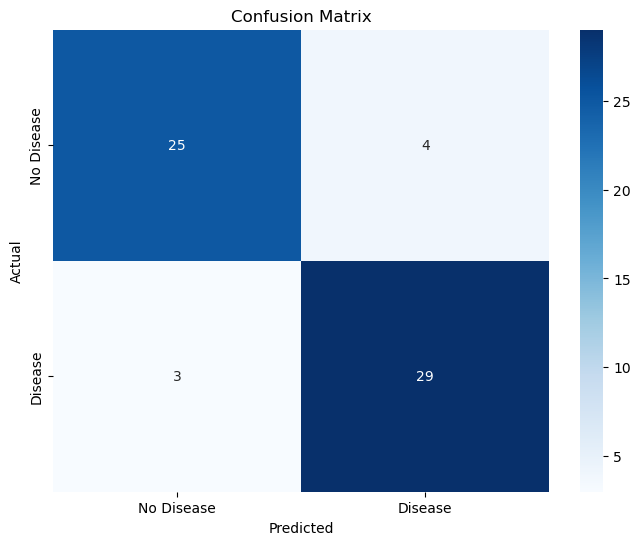

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

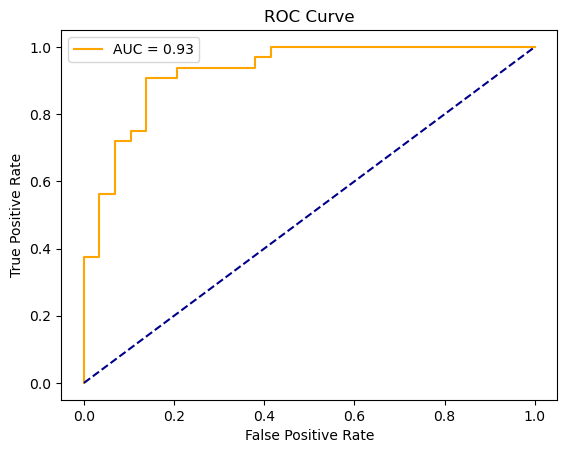

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities instead of just 0s and 1s
y_probs = model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, color='orange', label=f'AUC = {roc_auc_score(y_test, y_probs):.2f}')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

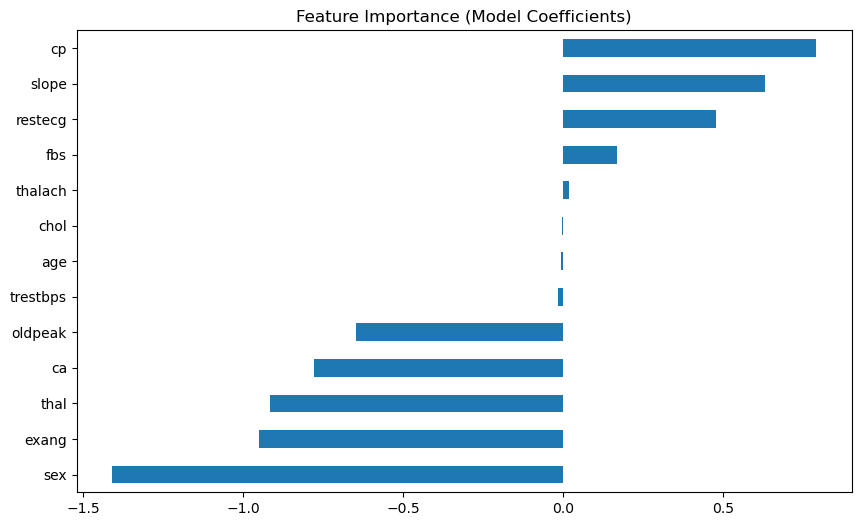

In [29]:


# Create a series with feature names and their coefficients
importance = pd.Series(model.coef_[0], index=x.columns)

# Plot the top features
importance.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance (Model Coefficients)')
plt.show()